# Advanced EDA: Visualisasi Dataset Sampah
Setelah data quality & cleaning, kita lihat distribusi ukuran, aspect ratio, sample gambar, dan warna per kelas.

> **Note:** Jalankan setelah `data_quality.ipynb` dan `remove_test_leakage.ipynb`.

In [7]:
import os
import random
from collections import defaultdict
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

%matplotlib inline

def _safe_path(p):
    p = str(p)
    if len(p) > 240 and not p.startswith('\\\\?\\'):
        return '\\\\?\\' + p
    return p

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
TRAIN_DIR = PROJECT_ROOT / 'data' / 'raw' / 'train'
CLASS_LABELS = {0: 'Recyclable', 1: 'Electronic', 2: 'Organic'}
CLASS_COLORS = ['#4CAF50', '#FF9800', '#2196F3']

In [8]:
# Extract metadata: width, height, aspect ratio, file size, mean RGB
metadata = defaultdict(list)
total = 0

for cls_folder in sorted(os.listdir(TRAIN_DIR)):
    cls_path = TRAIN_DIR / cls_folder
    if not cls_path.is_dir():
        continue
    total_files = len(list(cls_path.iterdir()))
    print(f'Scanning {cls_folder} ({total_files} images)...')
    for fpath in cls_path.iterdir():
        try:
            with open(_safe_path(fpath), 'rb') as f:
                buf = BytesIO(f.read())
            with Image.open(buf) as img:
                w, h = img.size
                img_rgb = img.convert('RGB')
                arr = np.array(img_rgb, dtype=np.float32)
                mean_rgb = tuple(arr.mean(axis=(0, 1)).tolist())

            metadata[cls_folder].append({
                'cls': cls_folder,
                'fname': fpath.name,
                'width': w,
                'height': h,
                'aspect': w / h if h > 0 else 1,
                'size_kb': fpath.stat().st_size / 1024,
                'mean_rgb': mean_rgb,
            })
            total += 1
        except Exception as e:
            print(f'  SKIP: {fpath.name} -> {e}')

print(f'\nTotal metadata collected: {total}')

Scanning 0_Recyclable (9990 images)...
Scanning 1_Electronic (3929 images)...
  SKIP: 1.tumpukan-e-limbah-yang-kacau-dari-laptop-dan-suku-cadang-komputer-yang-dibuang-representasi-visual-yang-luar-biasa-dari-masalah-limbah-elektronik-yang-berkembang-dan-kebutuhan-akan-solusi-daur-ulang-berkelanjutan_73523-11403.jpg -> [WinError 3] The system cannot find the path specified: 'd:\\Kuliah\\LOMBA\\Satria-Data\\main\\big-data-big-trouble\\data\\raw\\train\\1_Electronic\\1.tumpukan-e-limbah-yang-kacau-dari-laptop-dan-suku-cadang-komputer-yang-dibuang-representasi-visual-yang-luar-biasa-dari-masalah-limbah-elektronik-yang-berkembang-dan-kebutuhan-akan-solusi-daur-ulang-berkelanjutan_73523-11403.jpg'
  SKIP: 12.pile-discarded-motherboards-cpus-cables-disc-drives-hijacked-hardware-heap-concept-electronic-waste-tech-recycling-hardware-reuse-sustainable-technology-environmental-impact_864588-263287.jpg -> [WinError 3] The system cannot find the path specified: 'd:\\Kuliah\\LOMBA\\Satria-Data\\main

---
## 1. Distribusi Ukuran Gambar per Kelas

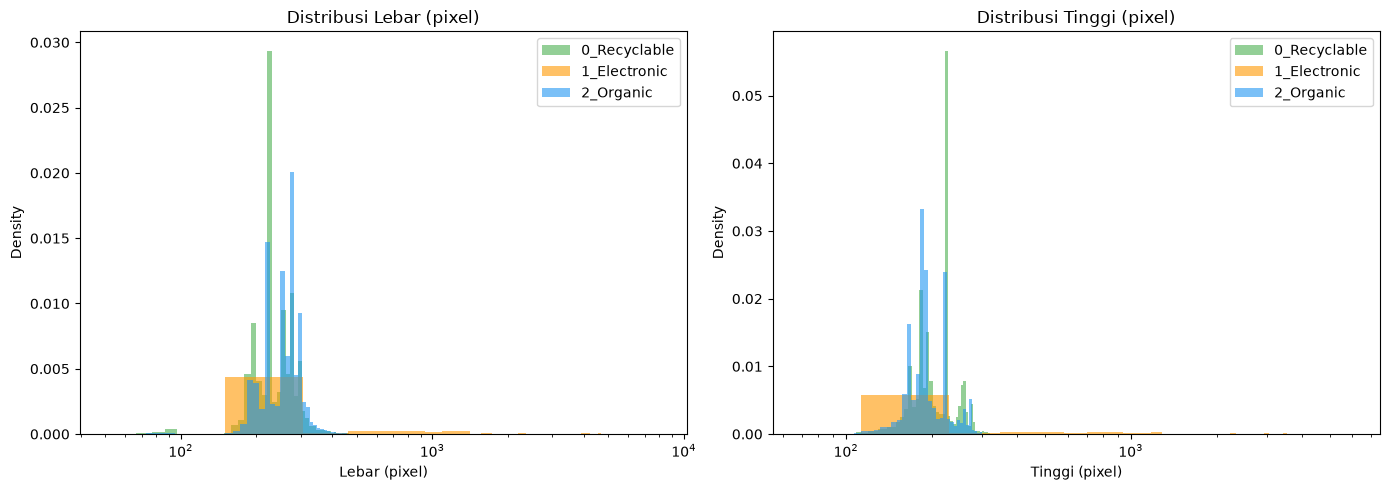

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label, unit in [
    (axes[0], 'width', 'Lebar (pixel)', 'px'),
    (axes[1], 'height', 'Tinggi (pixel)', 'px'),
]:
    for idx, (cls_name, items) in enumerate(sorted(metadata.items())):
        vals = [m[metric] for m in items]
        ax.hist(vals, bins=50, alpha=0.6, color=CLASS_COLORS[idx], label=cls_name, density=True)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'Distribusi {label}')
    ax.legend()
    ax.set_xscale('log')

plt.tight_layout()
plt.show()

In [14]:
# Table: min, max, median per class
print(f'{"Kelas":<20} {"Metric":<10} {"Min":>8} {"Max":>8} {"Median":>8}')
print('-' * 56)
for cls_name, items in sorted(metadata.items()):
    for metric in ['width', 'height', 'aspect']:
        vals = [m[metric] for m in items]
        label = 'Aspect' if metric == 'aspect' else ('Width' if metric == 'width' else 'Height')
        print(f'{cls_name:<20} {label:<10} {min(vals):>8.1f} {max(vals):>8.1f} {np.median(vals):>8.1f}')
    print()

Kelas                Metric          Min      Max   Median
--------------------------------------------------------
0_Recyclable         Width          56.0    569.0    225.0
0_Recyclable         Height         88.0    346.0    224.0
0_Recyclable         Aspect          0.2      6.5      1.0

1_Electronic         Width         150.0   8000.0    150.0
1_Electronic         Height        113.0   6000.0    150.0
1_Electronic         Aspect          0.3      4.0      1.0

2_Organic            Width          51.0    600.0    263.0
2_Organic            Height         69.0    383.0    190.0
2_Organic            Aspect          0.1      8.7      1.4



---
## 2. Aspect Ratio Distribution

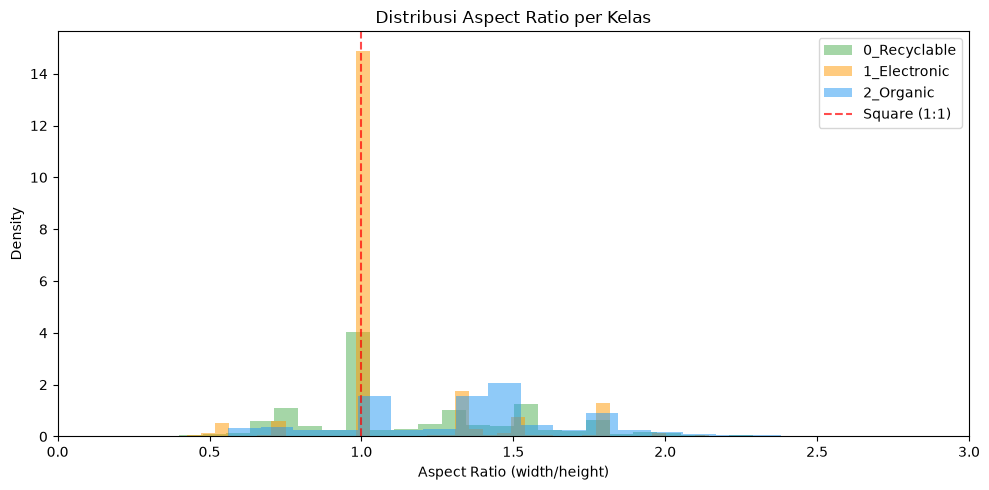

Overall aspect ratio range: 0.133 ~ 8.696
Overall aspect ratio median: 1.249


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

all_aspects = []
for idx, (cls_name, items) in enumerate(sorted(metadata.items())):
    vals = [m['aspect'] for m in items]
    all_aspects.extend(vals)
    ax.hist(vals, bins=80, alpha=0.5, color=CLASS_COLORS[idx], label=cls_name, density=True)

ax.axvline(1.0, color='red', linestyle='--', alpha=0.7, label='Square (1:1)')
ax.set_xlabel('Aspect Ratio (width/height)')
ax.set_ylabel('Density')
ax.set_title('Distribusi Aspect Ratio per Kelas')
ax.set_xlim(0, 3)
ax.legend()
plt.tight_layout()
plt.show()

print(f'Overall aspect ratio range: {min(all_aspects):.3f} ~ {max(all_aspects):.3f}')
print(f'Overall aspect ratio median: {np.median(all_aspects):.3f}')

---
## 3. Sample Gambar (Grid per Kelas)

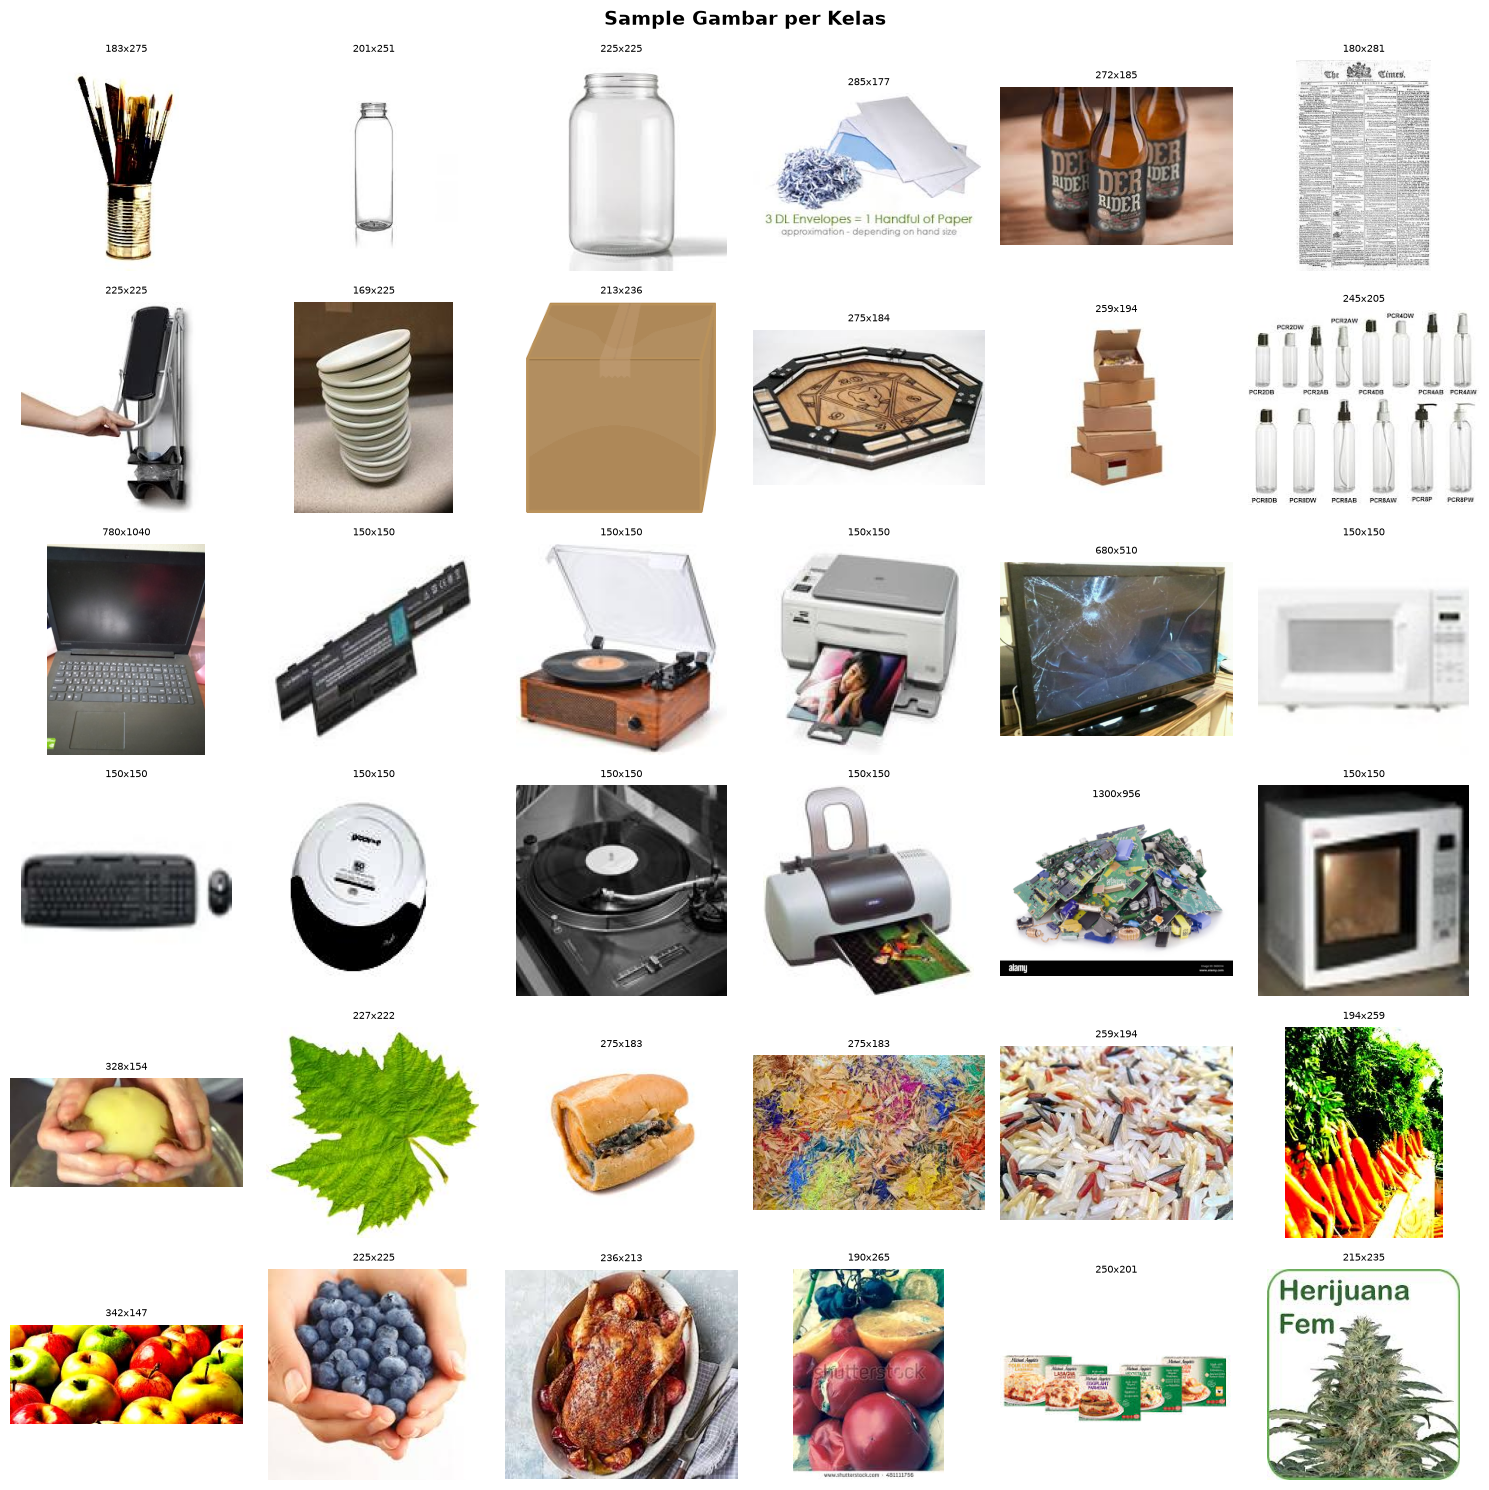

In [11]:
SAMPLES_PER_CLASS = 12
COLS = 6
ROWS = SAMPLES_PER_CLASS // COLS

fig, axes = plt.subplots(
    len(metadata) * ROWS, COLS,
    figsize=(2.5 * COLS, 2.5 * len(metadata) * ROWS)
)

for row_offset, (cls_name, items) in enumerate(sorted(metadata.items())):
    random.seed(42 + row_offset)
    samples = random.sample(items, min(SAMPLES_PER_CLASS, len(items)))

    for col in range(COLS):
        for row_inner in range(ROWS):
            idx = row_inner * COLS + col
            ax = axes[row_offset * ROWS + row_inner, col]
            if idx < len(samples):
                fpath = TRAIN_DIR / samples[idx]['cls'] / samples[idx]['fname']
                with open(_safe_path(fpath), 'rb') as f:
                    buf = BytesIO(f.read())
                with Image.open(buf) as img:
                    img_rgb = img.convert('RGB')
                    ax.imshow(img_rgb)
                ax.set_title(f"{samples[idx]['width']}x{samples[idx]['height']}", fontsize=7)
            ax.axis('off')

    # Label row group
    axes[row_offset * ROWS, 0].set_ylabel(cls_name, fontsize=12, fontweight='bold', rotation=0, labelpad=40, va='center')

plt.suptitle('Sample Gambar per Kelas', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

---
## 4. Distribusi Warna (RGB Mean per Kelas)

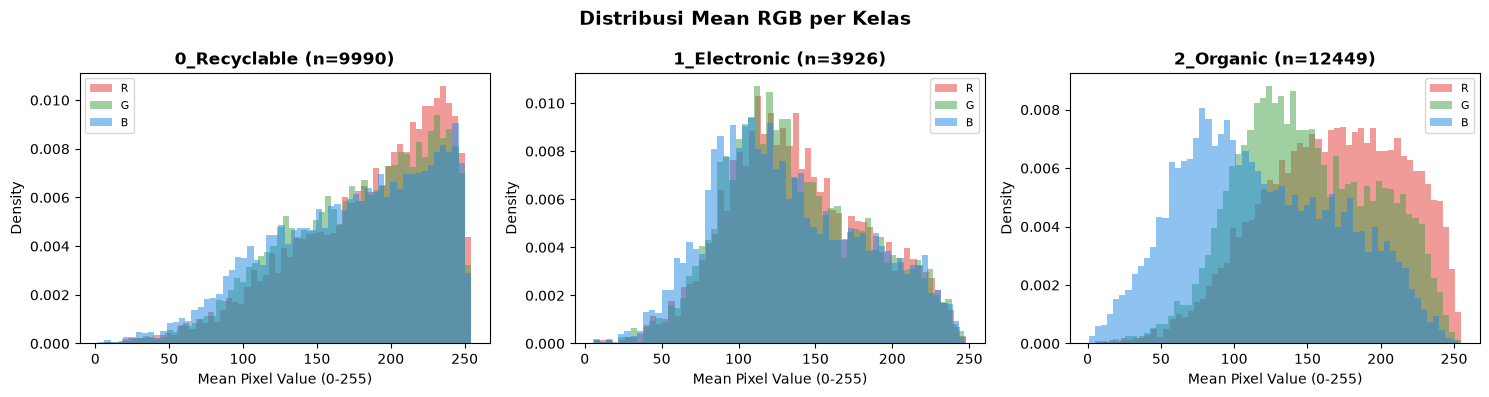

Kelas                  Mean R   Mean G   Mean B
----------------------------------------------
0_Recyclable            185.5    179.4    174.1
1_Electronic            138.9    136.2    131.8
2_Organic               167.5    149.4    118.4


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channels = ['R', 'G', 'B']
channel_colors = ['#E53935', '#43A047', '#1E88E5']

for idx, (cls_name, items) in enumerate(sorted(metadata.items())):
    means = np.array([m['mean_rgb'] for m in items])
    ax = axes[idx]
    for ch in range(3):
        ax.hist(means[:, ch], bins=60, alpha=0.5, color=channel_colors[ch], label=channels[ch], density=True)
    ax.set_title(f'{cls_name} (n={len(items)})', fontweight='bold')
    ax.set_xlabel('Mean Pixel Value (0-255)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Distribusi Mean RGB per Kelas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'{"Kelas":<20} {"Mean R":>8} {"Mean G":>8} {"Mean B":>8}')
print('-' * 46)
for cls_name, items in sorted(metadata.items()):
    avg = np.array([m['mean_rgb'] for m in items]).mean(axis=0)
    print(f'{cls_name:<20} {avg[0]:>8.1f} {avg[1]:>8.1f} {avg[2]:>8.1f}')

---
## 5. Summary Dataset

In [13]:
print(f'{"Metric":<30} {"Value"}')
print('-' * 50)
print(f'{"Total images":<30} {total}')
print()

all_widths = []
all_heights = []
all_sizes = []

for cls_name, items in sorted(metadata.items()):
    ws = [m['width'] for m in items]
    hs = [m['height'] for m in items]
    ks = [m['size_kb'] for m in items]
    all_widths.extend(ws)
    all_heights.extend(hs)
    all_sizes.extend(ks)
    print(f'{cls_name:<30} n={len(items)}')
    print(f'  {"Width range":<28} {min(ws)} x {max(ws)}')
    print(f'  {"Height range":<28} {min(hs)} x {max(hs)}')
    print(f'  {"File size range":<28} {min(ks):.1f} KB ~ {max(ks):.1f} KB')
    print()

print(f'Global metrics:')
print(f'  Width range:  {min(all_widths)} ~ {max(all_widths)}')
print(f'  Height range: {min(all_heights)} ~ {max(all_heights)}')
print(f'  File size:    {min(all_sizes):.1f} KB ~ {max(all_sizes):.1f} KB (median {np.median(all_sizes):.1f} KB)')

Metric                         Value
--------------------------------------------------
Total images                   26365

0_Recyclable                   n=9990
  Width range                  56 x 569
  Height range                 88 x 346
  File size range              0.8 KB ~ 32.3 KB

1_Electronic                   n=3926
  Width range                  150 x 8000
  Height range                 113 x 6000
  File size range              1.3 KB ~ 19262.7 KB

2_Organic                      n=12449
  Width range                  51 x 600
  Height range                 69 x 383
  File size range              1.3 KB ~ 36.2 KB

Global metrics:
  Width range:  51 ~ 8000
  Height range: 69 ~ 6000
  File size:    0.8 KB ~ 19262.7 KB (median 7.6 KB)
